<a href="https://colab.research.google.com/github/hadriman11/ACE6313-Food-Waste-SDG12/blob/main/Part_A_Preprocessing_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part A — Data Preprocessing
## ACE6313 Machine Learning — Food Waste (SDG 12)

**Author:** Student 1 (Data Preprocessing)

This notebook builds the preprocessing pipeline: cleaning, transformation, and reduction.
It outputs `clean_food_waste.csv` for Part B.


## 1. Imports & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

# Load the raw dataset
df = pd.read_csv('/content/drive/My Drive/Food Waste data and research - by country.csv')
print("Shape:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (214, 12)


,Country,combined figures (kg/capita/year),Household estimate (kg/capita/year),Household estimate (tonnes/year),Retail estimate (kg/capita/year),Retail estimate (tonnes/year),Food service estimate (kg/capita/year),Food service estimate (tonnes/year),Confidence in estimate,M49 code,Region,Source
0,Afghanistan,126,82,3109153,16,594982,28,1051783,Very Low Confidence,4,Southern Asia,https://www.unep.org/resources/report/unep-foo...
1,Albania,127,83,238492,16,45058,28,79651,Very Low Confidence,8,Southern Europe,https://www.unep.org/resources/report/unep-foo...
2,Algeria,135,91,3918529,16,673360,28,1190335,Very Low Confidence,12,Northern Africa,https://www.unep.org/resources/report/unep-foo...
3,Andorra,123,84,6497,13,988,26,1971,Low Confidence,20,Southern Europe,https://www.unep.org/resources/report/unep-foo...
4,Angola,144,100,3169523,16,497755,28,879908,Very Low Confidence,24,Sub-Saharan Africa,https://www.unep.org/resources/report/unep-foo...


In [3]:
# Column names and types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 12 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Country                                 214 non-null    object
 1   combined figures (kg/capita/year)       214 non-null    int64 
 2   Household estimate (kg/capita/year)     214 non-null    int64 
 3   Household estimate (tonnes/year)        214 non-null    int64 
 4   Retail estimate (kg/capita/year)        214 non-null    int64 
 5   Retail estimate (tonnes/year)           214 non-null    int64 
 6   Food service estimate (kg/capita/year)  214 non-null    int64 
 7   Food service estimate (tonnes/year)     214 non-null    int64 
 8   Confidence in estimate                  214 non-null    object
 9   M49 code                                214 non-null    int64 
 10  Region                                  214 non-null    object
 11  Source

In [4]:
# Summary statistics
df.describe()

,combined figures (kg/capita/year),Household estimate (kg/capita/year),Household estimate (tonnes/year),Retail estimate (kg/capita/year),Retail estimate (tonnes/year),Food service estimate (kg/capita/year),Food service estimate (tonnes/year),M49 code
count,214.000000,214.000000,2.140000e+02,214.000000,2.140000e+02,214.000000,2.140000e+02,214.000000
mean,126.794393,84.294393,2.658896e+06,15.116822,5.520454e+05,27.383178,1.138859e+06,433.971963
std,22.157879,18.313705,8.596906e+06,5.767840,2.195578e+06,6.508420,5.380459e+06,252.185786
min,61.000000,33.000000,8.500000e+02,3.000000,1.380000e+02,3.000000,2.760000e+02,4.000000
25%,115.000000,74.000000,6.831550e+04,13.000000,1.250925e+04,26.000000,2.239125e+04,219.000000
50%,123.000000,80.000000,5.205080e+05,16.000000,1.006500e+05,28.000000,1.884660e+05,432.000000
75%,137.750000,95.000000,2.111314e+06,16.000000,3.568158e+05,28.000000,6.307618e+05,645.250000
max,260.000000,189.000000,9.164621e+07,79.000000,2.242470e+07,90.000000,6.537774e+07,894.000000


## 2. Data Cleaning
Handle missing values, duplicates, and outliers.

In [5]:
# Missing values — this dataset has none, but we verify and report it
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Country                                   0
combined figures (kg/capita/year)         0
Household estimate (kg/capita/year)       0
Household estimate (tonnes/year)          0
Retail estimate (kg/capita/year)          0
Retail estimate (tonnes/year)             0
Food service estimate (kg/capita/year)    0
Food service estimate (tonnes/year)       0
Confidence in estimate                    0
M49 code                                  0
Region                                    0
Source                                    0
dtype: int64


In [6]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
# Drop columns not useful for modelling
# Source = just URLs, M49 code = country ID number
df = df.drop(columns=["Source", "M49 code"])
df.head()

,Country,combined figures (kg/capita/year),Household estimate (kg/capita/year),Household estimate (tonnes/year),Retail estimate (kg/capita/year),Retail estimate (tonnes/year),Food service estimate (kg/capita/year),Food service estimate (tonnes/year),Confidence in estimate,Region
0,Afghanistan,126,82,3109153,16,594982,28,1051783,Very Low Confidence,Southern Asia
1,Albania,127,83,238492,16,45058,28,79651,Very Low Confidence,Southern Europe
2,Algeria,135,91,3918529,16,673360,28,1190335,Very Low Confidence,Northern Africa
3,Andorra,123,84,6497,13,988,26,1971,Low Confidence,Southern Europe
4,Angola,144,100,3169523,16,497755,28,879908,Very Low Confidence,Sub-Saharan Africa


Outliers found: 9
                Country  combined figures (kg/capita/year)
10              Austria                                 76
17              Belgium                                 80
77               Greece                                175
95               Israel                                178
116            Malaysia                                260
139             Nigeria                                233
158  Russian Federation                                 75
159              Rwanda                                208
175            Slovenia                                 61


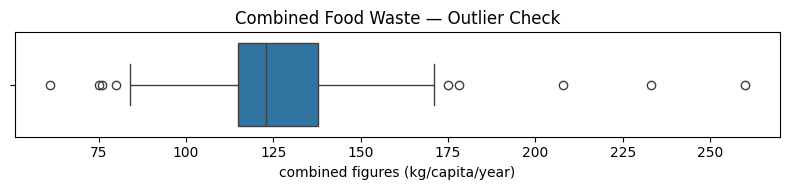

In [8]:
import os

# Outlier detection using the IQR method on the main target figure
col = "combined figures (kg/capita/year)"
Q1, Q3 = df[col].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outlier_mask = (df[col] < lower) | (df[col] > upper)
print(f"Outliers found: {outlier_mask.sum()}")
print(df.loc[outlier_mask, ["Country", col]])

# Visualise with a boxplot
plt.figure(figsize=(8,2))
sns.boxplot(x=df[col])
plt.title("Combined Food Waste — Outlier Check")
plt.tight_layout()

# Create the directory if it doesn't exist
output_dir = "../report/"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, "outlier_boxplot.png"), dpi=150)
plt.show()

# DECISION: document in the report whether you keep or remove these.
# By default we KEEP them (real countries, not data errors).

## 3. Data Transformation
Encoding, feature engineering, and scaling.

In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode the target (ordered: Very Low < Low < Medium < High)
conf_map = {"Very Low Confidence": 0, "Low Confidence": 1,
            "Medium Confidence": 2, "High Confidence": 3}
df["Confidence_encoded"] = df["Confidence in estimate"].map(conf_map)
print(df["Confidence_encoded"].value_counts().sort_index())

Confidence_encoded
0    130
1     61
2     13
3     10
Name: count, dtype: int64


In [10]:
# Encode Region (nominal — label encoding for tree models)
le = LabelEncoder()
df["Region_encoded"] = le.fit_transform(df["Region"])
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Australia and New Zealand': np.int64(0), 'Central Asia': np.int64(1), 'Eastern Asia': np.int64(2), 'Eastern Europe': np.int64(3), 'Latin America and the Caribbean': np.int64(4), 'Melanesia': np.int64(5), 'Micronesia': np.int64(6), 'Northern Africa': np.int64(7), 'Northern America': np.int64(8), 'Northern Europe': np.int64(9), 'Polynesia': np.int64(10), 'South-eastern Asia': np.int64(11), 'Southern Asia': np.int64(12), 'Southern Europe': np.int64(13), 'Sub-Saharan Africa': np.int64(14), 'Western Asia': np.int64(15), 'Western Europe': np.int64(16)}


In [11]:
# Feature engineering: each sector's share of total waste
df["household_ratio"] = (df["Household estimate (kg/capita/year)"]
                         / df["combined figures (kg/capita/year)"])
df["retail_ratio"] = (df["Retail estimate (kg/capita/year)"]
                      / df["combined figures (kg/capita/year)"])
df["foodservice_ratio"] = (df["Food service estimate (kg/capita/year)"]
                           / df["combined figures (kg/capita/year)"])
df[["household_ratio","retail_ratio","foodservice_ratio"]].head()

,household_ratio,retail_ratio,foodservice_ratio
0,0.650794,0.126984,0.222222
1,0.653543,0.125984,0.220472
2,0.674074,0.118519,0.207407
3,0.682927,0.105691,0.211382
4,0.694444,0.111111,0.194444


In [12]:
# Feature scaling (StandardScaler) on numeric features
numeric_cols = [
    "combined figures (kg/capita/year)",
    "Household estimate (kg/capita/year)",
    "Retail estimate (kg/capita/year)",
    "Food service estimate (kg/capita/year)",
    "household_ratio", "retail_ratio", "foodservice_ratio",
]
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df[numeric_cols].head()

,combined figures (kg/capita/year),Household estimate (kg/capita/year),Retail estimate (kg/capita/year),Food service estimate (kg/capita/year),household_ratio,retail_ratio,foodservice_ratio
0,-0.035936,-0.125577,0.153480,0.094995,-0.188037,0.270371,0.073524
1,0.009301,-0.070845,0.153480,0.094995,-0.141933,0.235596,0.036132
2,0.371193,0.367011,0.153480,0.094995,0.202311,-0.024053,-0.243065
3,-0.171645,-0.016113,-0.367865,-0.213020,0.350747,-0.470177,-0.158126
4,0.778321,0.859598,0.153480,0.094995,0.543865,-0.281674,-0.520080


## 4. Data Reduction
Correlation analysis + PCA.

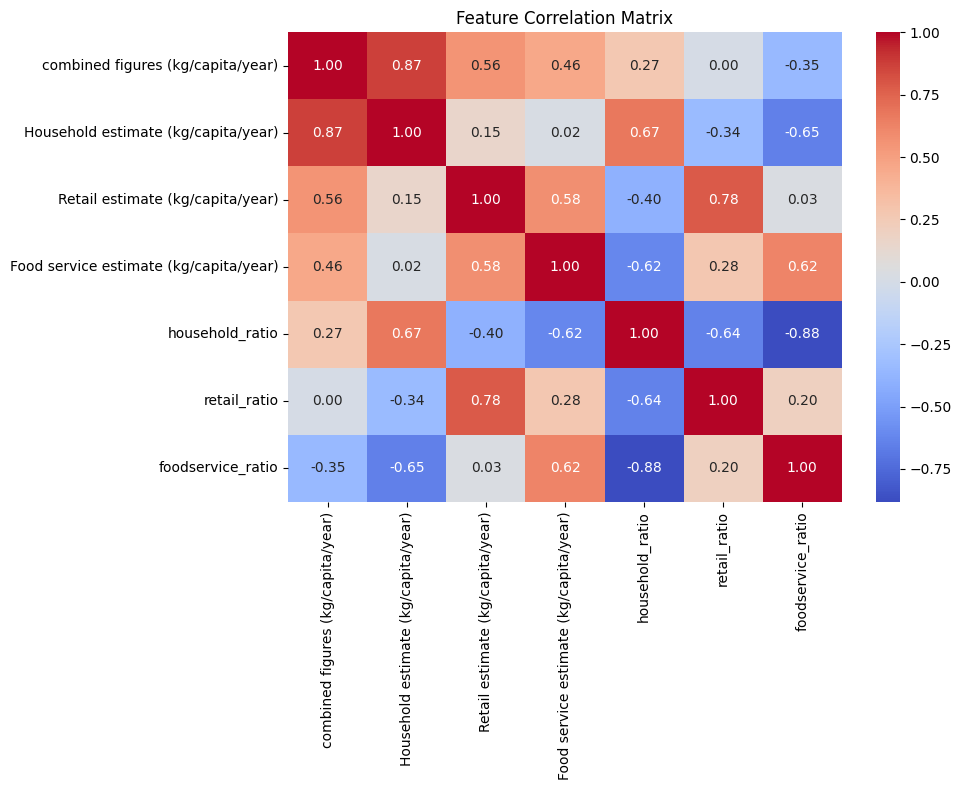

In [13]:
# Correlation heatmap to find redundant features
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("../report/correlation_heatmap.png", dpi=150)
plt.show()

Explained variance per component: [0.474 0.354 0.156 0.013]
Cumulative: [0.474 0.829 0.984 0.997]


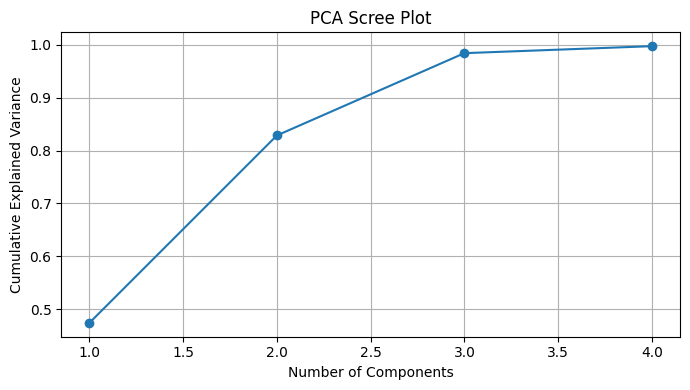

In [14]:
from sklearn.decomposition import PCA

# PCA to reduce dimensionality
pca = PCA(n_components=4)
pca_features = pca.fit_transform(df[numeric_cols])

print("Explained variance per component:", pca.explained_variance_ratio_.round(3))
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_).round(3))

# Scree plot
plt.figure(figsize=(7,4))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot")
plt.grid(True)
plt.tight_layout()
plt.savefig("../report/pca_scree.png", dpi=150)
plt.show()

## 5. Save Cleaned Dataset for Part B

In [15]:
import os

# Final feature set for modelling
features = numeric_cols + ["Region_encoded"]
clean = df[features + ["Confidence_encoded"]].dropna()

# Create the directory in Google Drive if it doesn't exist
drive_output_dir = "/content/drive/My Drive"
os.makedirs(drive_output_dir, exist_ok=True)

clean.to_csv(os.path.join(drive_output_dir, "clean_food_waste.csv"), index=False)
print(f"Saved clean_food_waste.csv to {drive_output_dir} with shape: {clean.shape}")
clean.head()

Saved clean_food_waste.csv to /content/drive/My Drive with shape: (214, 9)


,combined figures (kg/capita/year),Household estimate (kg/capita/year),Retail estimate (kg/capita/year),Food service estimate (kg/capita/year),household_ratio,retail_ratio,foodservice_ratio,Region_encoded,Confidence_encoded
0,-0.035936,-0.125577,0.153480,0.094995,-0.188037,0.270371,0.073524,12,0
1,0.009301,-0.070845,0.153480,0.094995,-0.141933,0.235596,0.036132,13,0
2,0.371193,0.367011,0.153480,0.094995,0.202311,-0.024053,-0.243065,7,0
3,-0.171645,-0.016113,-0.367865,-0.213020,0.350747,-0.470177,-0.158126,13,1
4,0.778321,0.859598,0.153480,0.094995,0.543865,-0.281674,-0.520080,14,0


---
### Summary (write this up in the report)
- **Cleaning:** verified no missing values, no duplicates; dropped Source/M49; checked outliers via IQR.
- **Transformation:** encoded target & region, engineered 3 sector-ratio features, scaled with StandardScaler.
- **Reduction:** correlation heatmap + PCA (note how many components capture ~95% variance).
